# Unsupervised Learning

# Install packages
Only run if you need to install packages

In [ ]:
%pip install rdkit
%pip install pandas
%pip install scikit-learn
%pip install matplotlib
%pip install numpy
%pip install umap-learn

# PCA and Unsupervised Learning
The PCA we discussed last time can also be used for unsupervised learning, clusters can sometimes be seen in the reduced data. We will look at this for reduced representation of molecular features

In [2]:
import pandas as pd

#counts the number of times an amino acid occurs in the sequence
def count_amino_acid(seq, amino_acid):
    return seq.count(amino_acid)

df = pd.read_csv("full_promelt_seq.csv")
#remove rows with invalid amino acids
df = df[df["sequence"].str.count("X")==0]
df = df[df["sequence"].str.count("U")==0]
df = df[df["sequence"].str.count("Z")==0]
df = df[df["sequence"].str.count("B")==0]

#remove rows with very long sequences
df = df[df["Length"]<1000]

#this will use the string count function on all items in the sequence column (similar to the apply we covered before)
df["A"] = df["sequence"].str.count('A')
df["C"] = df["sequence"].str.count('C')
df["D"] = df["sequence"].str.count('D')
df["E"] = df["sequence"].str.count('E')
df["F"] = df["sequence"].str.count('F')
df["G"] = df["sequence"].str.count('G')
df["H"] = df["sequence"].str.count('H')
df["I"] = df["sequence"].str.count('I')
df["K"] = df["sequence"].str.count('K')
df["L"] = df["sequence"].str.count('L')
df["M"] = df["sequence"].str.count('M')
df["N"] = df["sequence"].str.count('N')
df["P"] = df["sequence"].str.count('P')
df["Q"] = df["sequence"].str.count('Q')
df["R"] = df["sequence"].str.count('R')
df["S"] = df["sequence"].str.count('S')
df["T"] = df["sequence"].str.count('T')
df["V"] = df["sequence"].str.count('V')
df["W"] = df["sequence"].str.count('W')
df["Y"] = df["sequence"].str.count('Y')

#define features
X = df[["A","C","D","E","F","G","H","I","K","L","M","N",\
                               "P","Q","R","S","T","V","W","Y"]]

#use less data because otherwise UMAP will be too slow
X = X[0:1000]

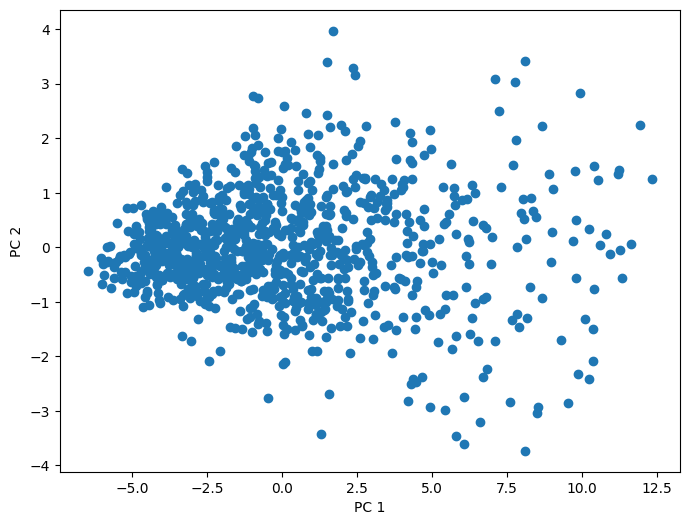

In [3]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

#assemble the pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),   
    ("pca", PCA(n_components=2))
])

#note this dataset already has some descriptors so we do not need to calculate them ourselves with rdkit
reduced_data = pipe.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.scatter(reduced_data[:,0],reduced_data[:,1])
plt.show()

# tSNE and UMAP
Compare the tSNE and UMAP results to PCA - which has more obvious clusters?
<br/>
Note that these methods have hyperparameters that will affect the result


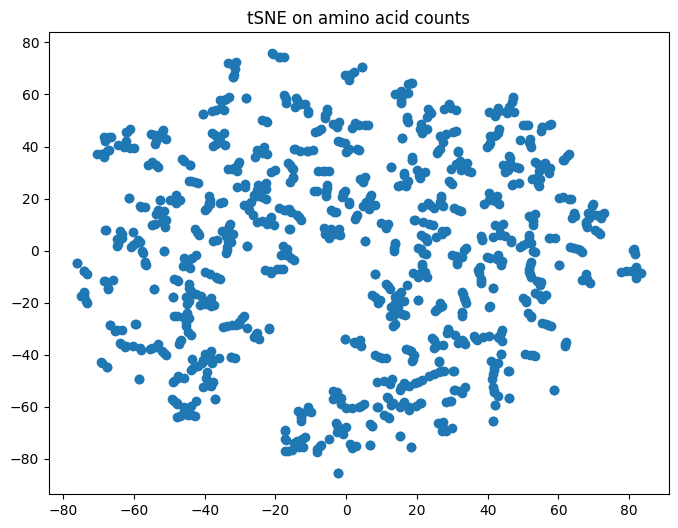

C:\Users\allis\anaconda3\envs\AI_class\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


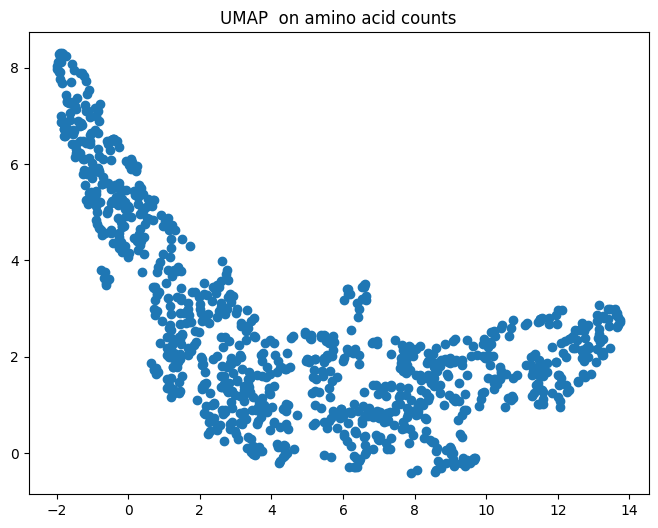

In [5]:
#tSNE and UMAP applied to descriptors
from sklearn.manifold import TSNE
import umap

X_tsne = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(X)
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:,0],X_tsne[:,1])
plt.title("tSNE on amino acid counts")
plt.show()

X_umap = umap.UMAP(n_neighbors=5, random_state=42).fit(X)
plt.figure(figsize=(8, 6))
plt.scatter(X_umap.embedding_[:,0],X_umap.embedding_[:,1])
plt.title("UMAP  on amino acid counts")
plt.show()


# K-Means Clustering

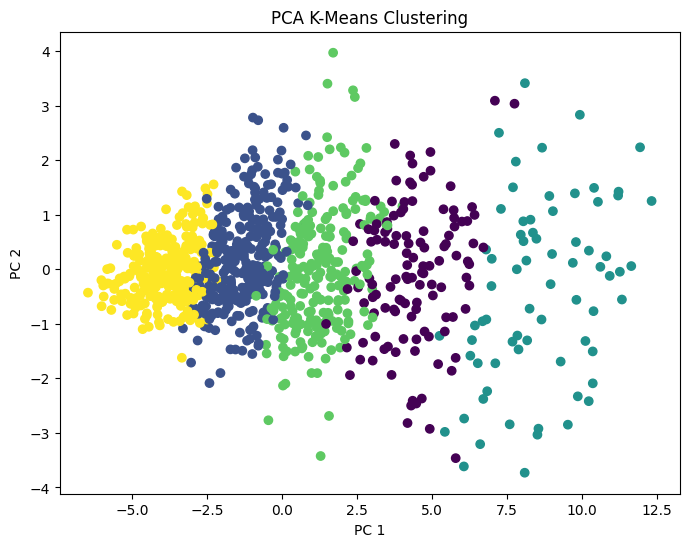

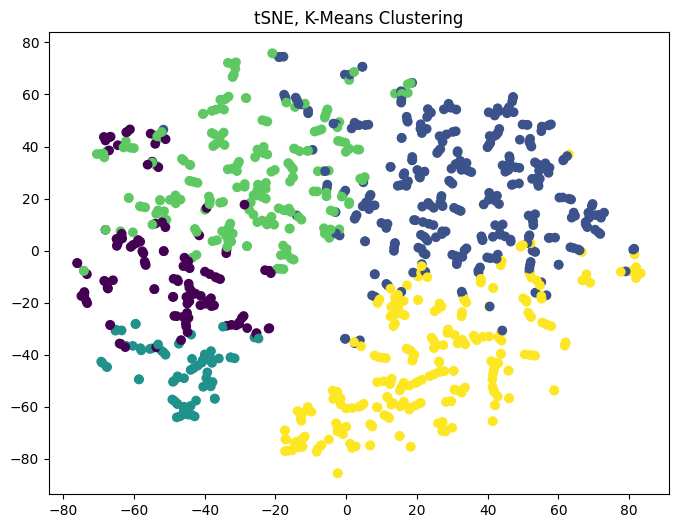

In [6]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(X)

plt.figure(figsize=(8, 6))
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.scatter(reduced_data[:,0],reduced_data[:,1],c=kmeans.labels_, cmap='viridis')
plt.title("PCA K-Means Clustering")
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:,0],X_tsne[:,1],c=kmeans.labels_, cmap='viridis')
plt.title("tSNE, K-Means Clustering")
plt.show()

# Affinity Propagation

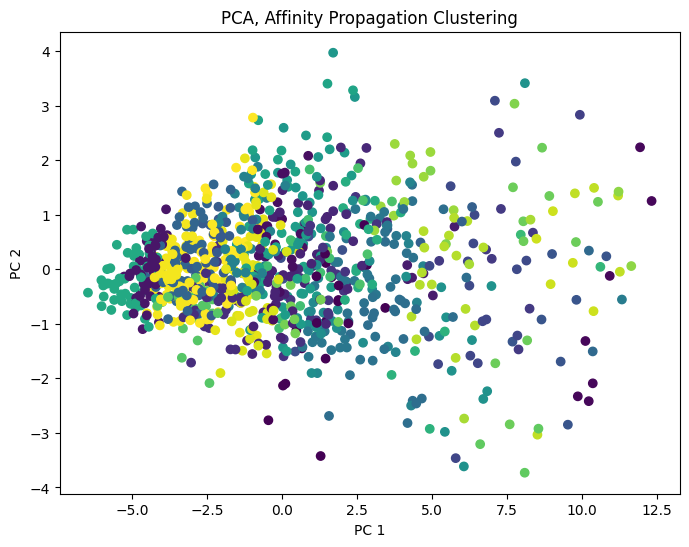

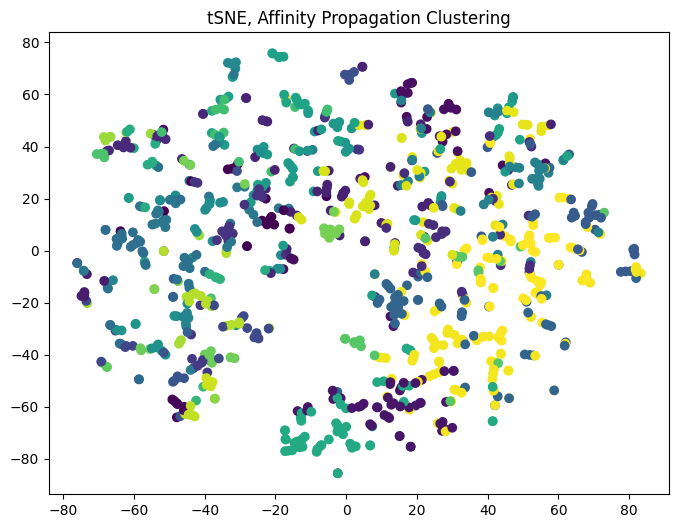

In [7]:
from sklearn.cluster import AffinityPropagation

affinity_prop = AffinityPropagation(random_state=5).fit(X)

plt.figure(figsize=(8, 6))
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.scatter(reduced_data[:,0],reduced_data[:,1],c=affinity_prop.labels_, cmap='viridis')
plt.title("PCA, Affinity Propagation Clustering")
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:,0],X_tsne[:,1],c=affinity_prop.labels_, cmap='viridis')
plt.title("tSNE, Affinity Propagation Clustering")
plt.show()


# DBSCAN and HDBSCAN

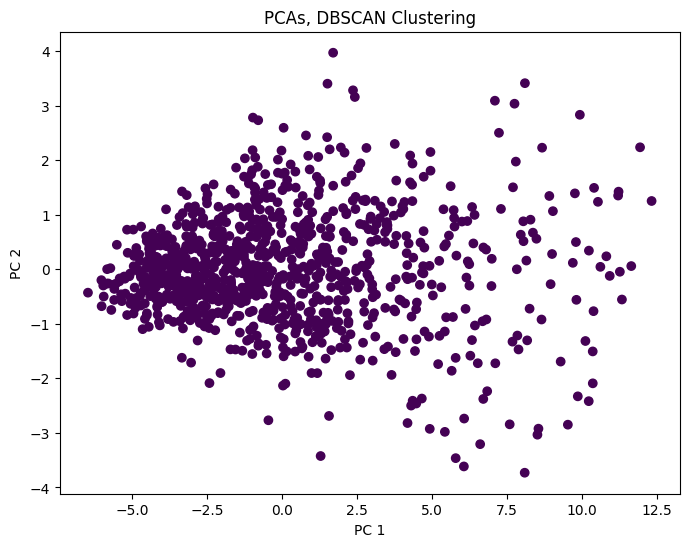

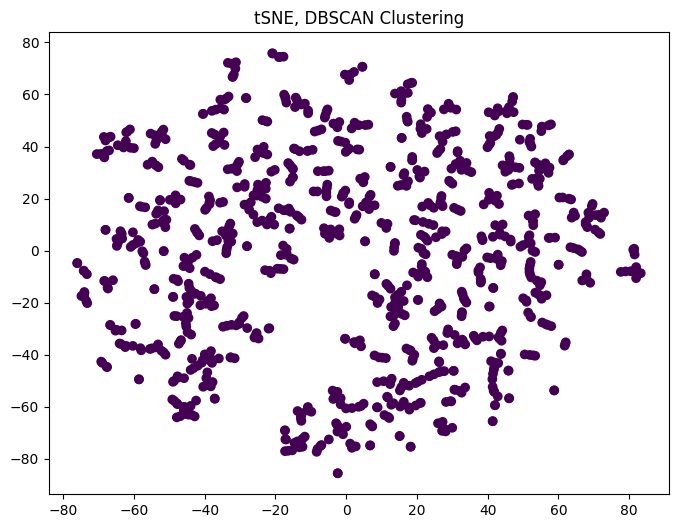

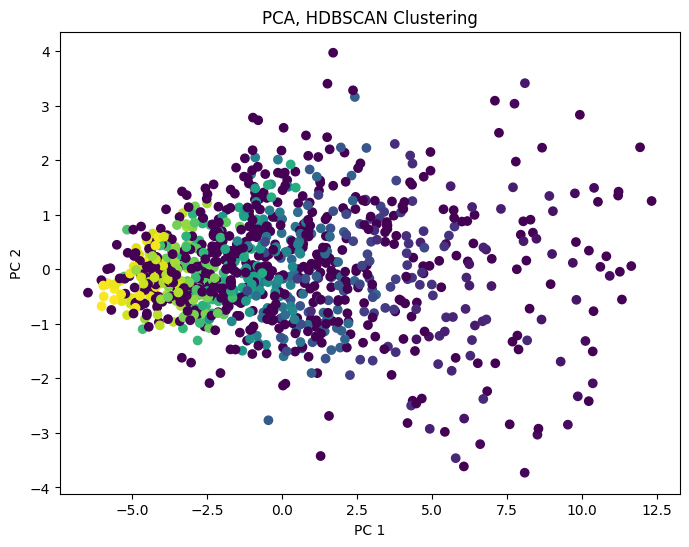

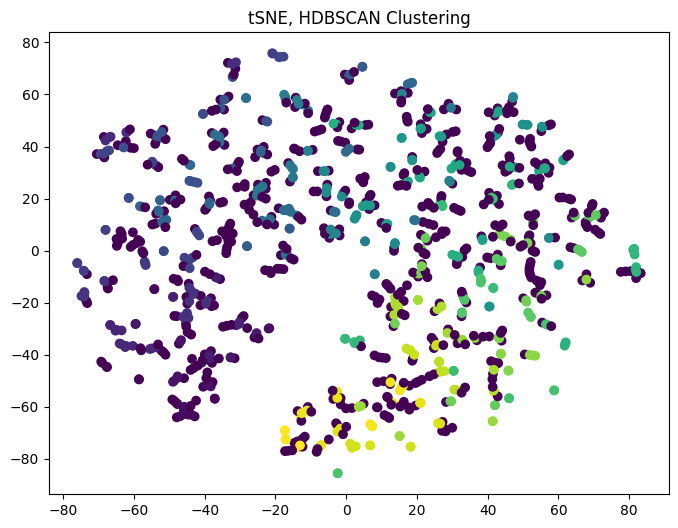

In [8]:
from sklearn.cluster import DBSCAN, HDBSCAN

dbscan_clustering = DBSCAN(eps=3, min_samples=2).fit(X)
hdb_clustering = HDBSCAN(copy=True, min_cluster_size=2).fit(X)

plt.figure(figsize=(8, 6))
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.scatter(reduced_data[:,0],reduced_data[:,1],c=dbscan_clustering.labels_, cmap='viridis')
plt.title("PCAs, DBSCAN Clustering")
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:,0],X_tsne[:,1],c=dbscan_clustering.labels_, cmap='viridis')
plt.title("tSNE, DBSCAN Clustering")
plt.show()

plt.figure(figsize=(8, 6))
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.scatter(reduced_data[:,0],reduced_data[:,1],c=hdb_clustering.labels_, cmap='viridis')
plt.title("PCA, HDBSCAN Clustering")
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:,0],X_tsne[:,1],c=hdb_clustering.labels_, cmap='viridis')
plt.title("tSNE, HDBSCAN Clustering")
plt.show()

# Metrics
We will look at the Silhouette score and other metrics calculated on the descriptors. We will also look at the Silhouette score calculated on the Tanimoto similarity converted to a distance.

In [13]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

#DBSCAN only found one cluster so metrics cannot be calculated, so these lines are commented out
print("Silhouette Scores")
print("kmeans " + str(silhouette_score(X, kmeans.labels_)))
print("Affinity Propagation " + str(silhouette_score(X, affinity_prop.labels_)))
#print("DBSCAN " + str(silhouette_score(X, dbscan_clustering.labels_)))
print("HDBSCAN " + str(silhouette_score(X, hdb_clustering.labels_)))

print("Calinski Harabasz Scores")
print("kmeans " + str(calinski_harabasz_score(X, kmeans.labels_)))
print("Affinity Propagation " + str(calinski_harabasz_score(X, affinity_prop.labels_)))
#print("DBSCAN " + str(calinski_harabasz_score(X, dbscan_clustering.labels_)))
print("HDBSCAN " + str(calinski_harabasz_score(X, hdb_clustering.labels_)))

print("Davies Bouldin Scores")
print("kmeans " + str(davies_bouldin_score(X, kmeans.labels_)))
print("Affinity Propagation " + str(davies_bouldin_score(X, affinity_prop.labels_)))
#print("DBSCAN " + str(davies_bouldin_score(X, dbscan_clustering.labels_)))
print("HDBSCAN " + str(davies_bouldin_score(X, hdb_clustering.labels_)))


Silhouette Scores
kmeans 0.20607882093073637
Affinity Propagation 0.049766830866105956
HDBSCAN -0.2490379109428027
Calinski Harabasz Scores
kmeans 622.7568553444817
Affinity Propagation 91.00600610645797
HDBSCAN 4.005961166626153
Davies Bouldin Scores
kmeans 1.5280090225602407
Affinity Propagation 2.030321693884106
HDBSCAN 1.7843652481411487


# Choosing number of clusters with metrics
For methods like K-means that requires choice of number of clusters, we can see how different cluster sizes effect the Silhouette score, the maximum of the curve will be the ideal number of clusters.

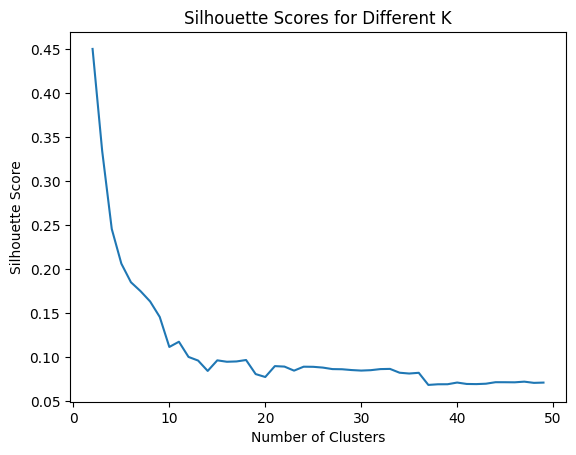

In [15]:
silhouette_scores = []
for k in range(2,50):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto").fit(X)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))
    
plt.plot(range(2,50), silhouette_scores)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different K")
plt.show()